Đang tải dữ liệu...

THỐNG KÊ TỔNG QUAN BỘ DỮ LIỆU
- Tổng số file âm thanh: 559,938
- Tổng số người nói (speakers): 2,186

- Tổng thời lượng âm thanh: 424.30 giờ
- Thời lượng trung bình mỗi file: 2.728 giây
- Thời lượng ngắn nhất: 2.500 giây
- Thời lượng dài nhất: 3.500 giây

THỐNG KÊ THEO NGƯỜI NÓI (SPEAKER)
- Trung bình số file mỗi người: 256.1 file
- Người có nhiều file nhất: 36,551 file
- Người có ít file nhất: 1 file

ĐÁNH GIÁ CHẤT LƯỢNG (Dành cho Speaker Verification)
- Số người có dưới 5 file: 405 (18.5%)
- Số người có tổng thời lượng dưới 1 phút: 856 (39.2%)



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27324\3554205315.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_speakers.index, y=top_speakers.values, ax=axes[0, 1], palette='magma')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27324\3554205315.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_duration_speakers.index, y=top_duration_speakers.values, ax=axes[1, 0], palette='crest')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_27324\3554205315.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='speaker_id', y='duration', 

Thành công! Đã lưu biểu đồ thành file: eda_charts_metadata_final.png


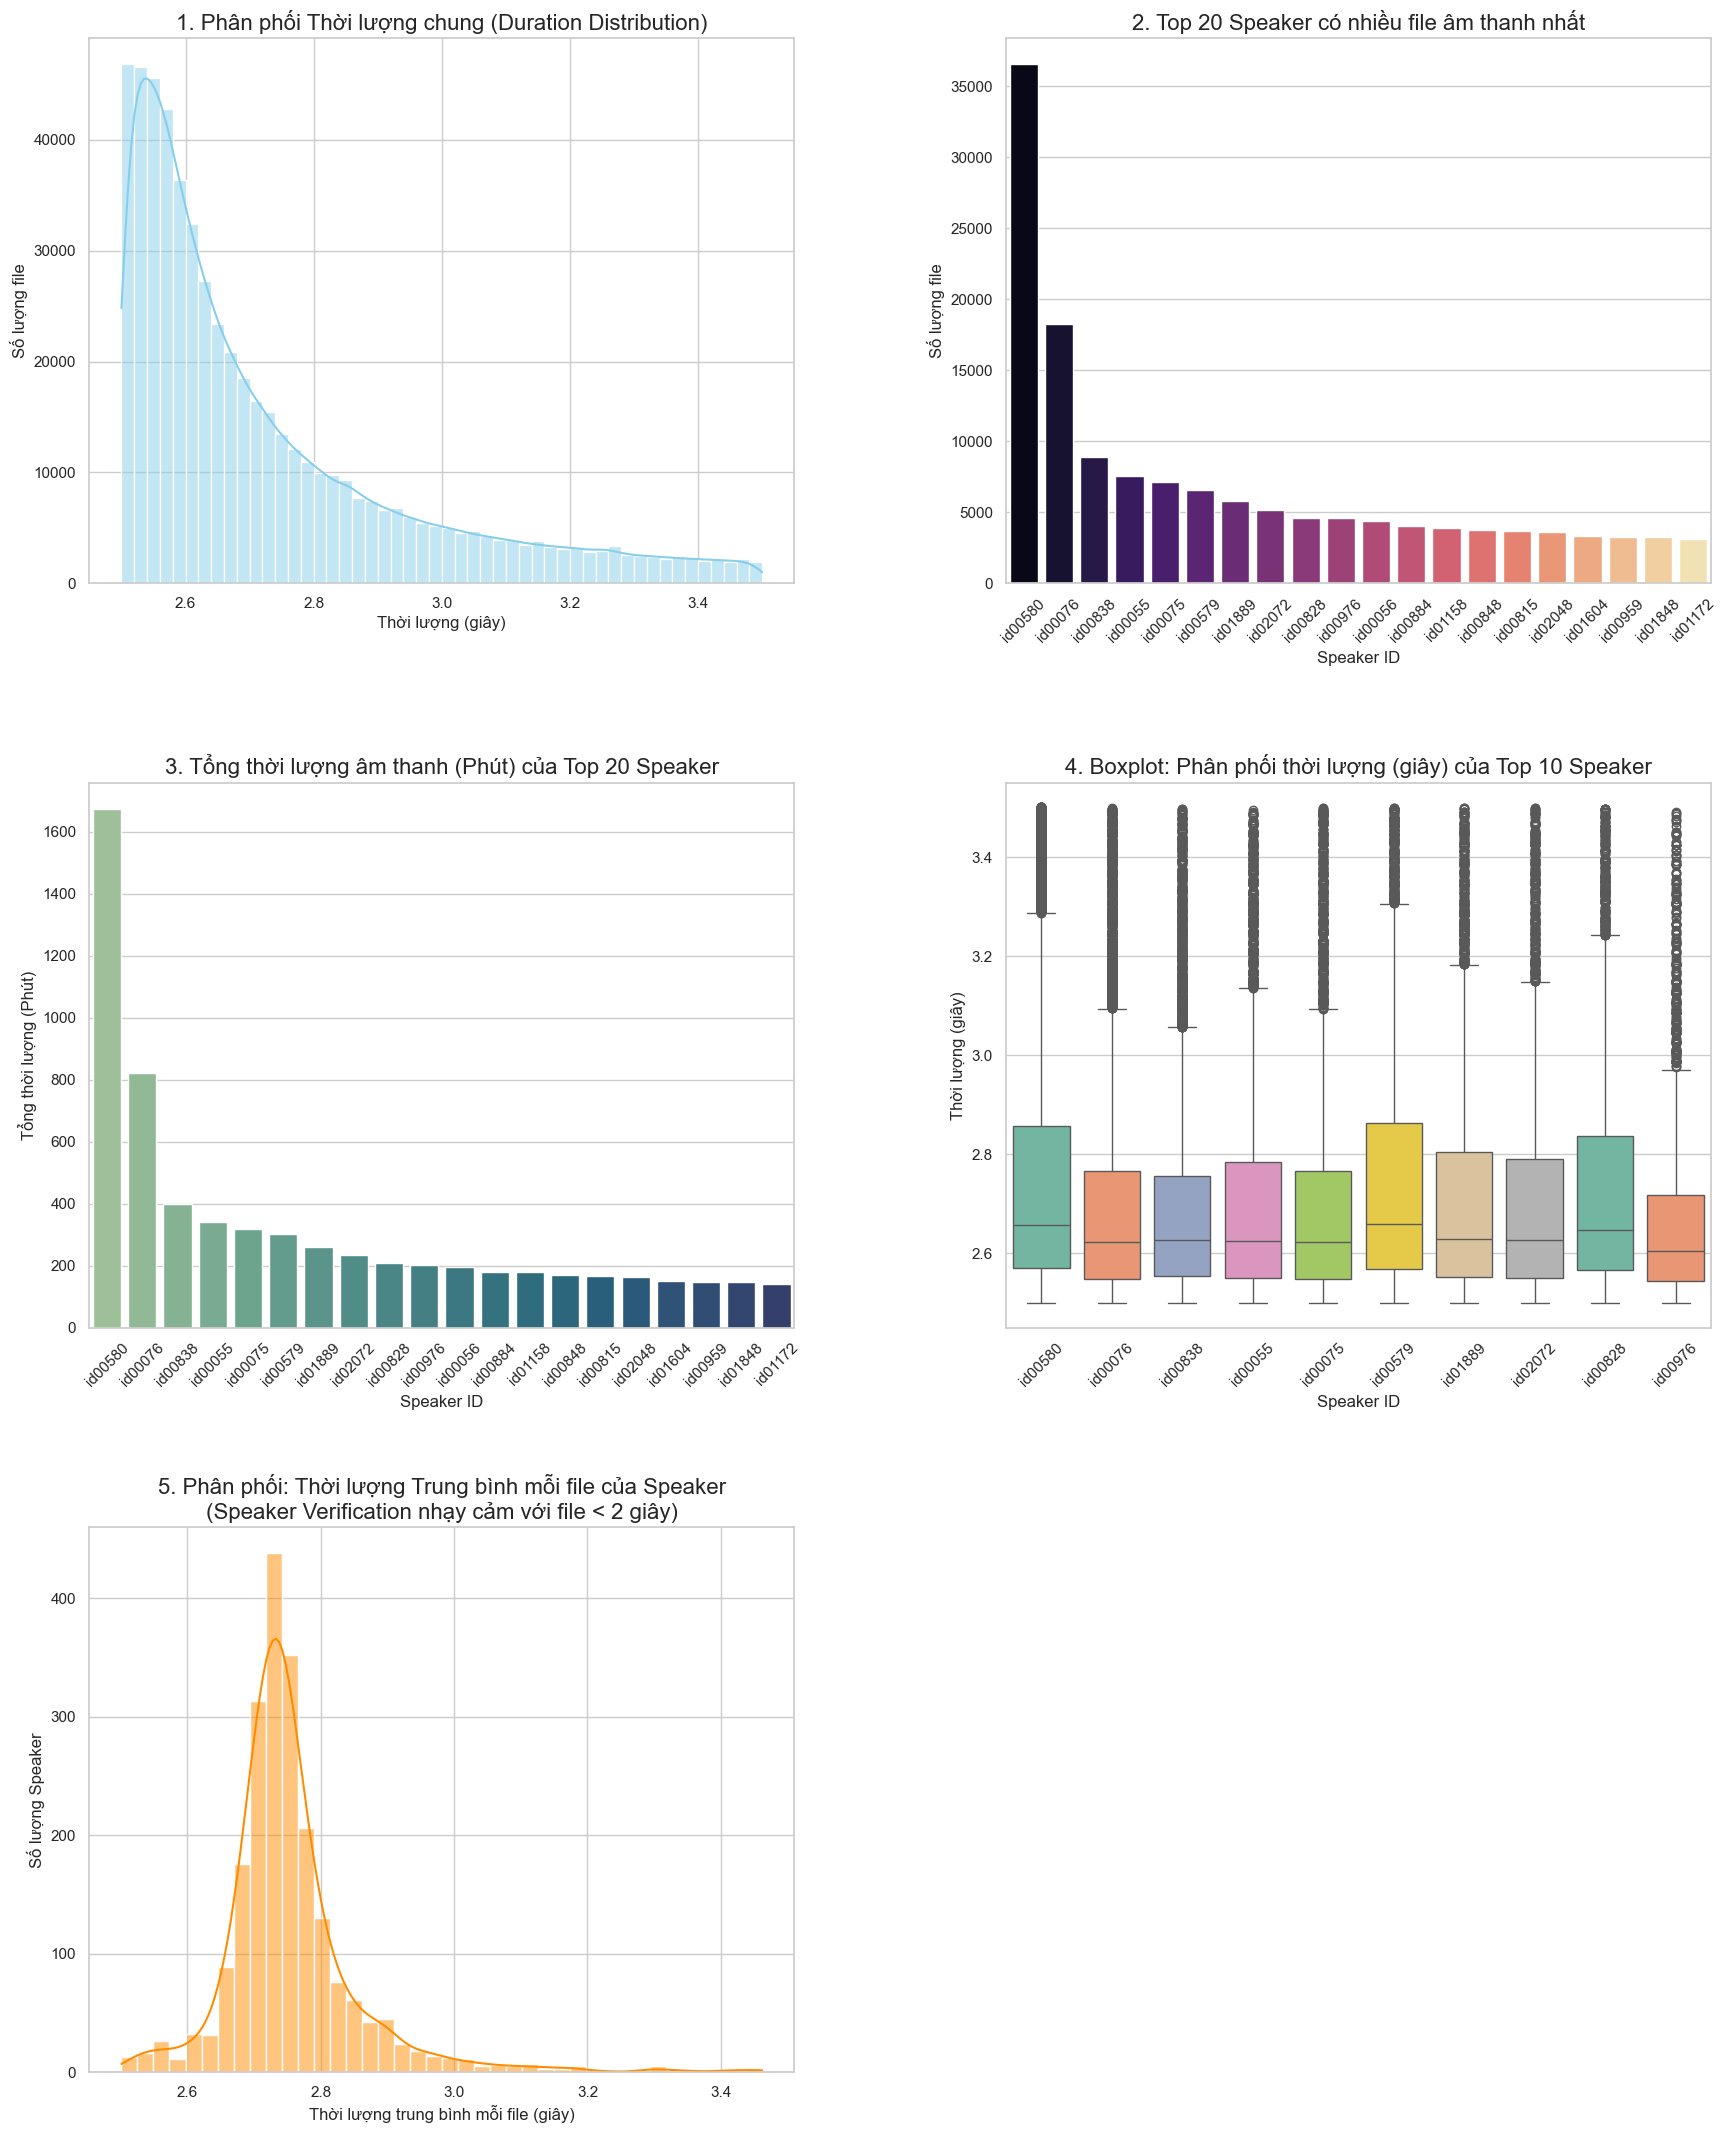

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")

# ==========================================
# 1. ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# ==========================================
print("Đang tải dữ liệu...")
df = pd.read_csv(r"D:\Study\7-SP26\DATxSLP\metadata_3s - Copy.csv")

# Xóa các cột trống 
cols_to_drop = [col for col in df.columns if 'Unnamed' in col]
df = df.drop(columns=cols_to_drop)

# ==========================================
# 2. IN RA CÁC THÔNG SỐ THỐNG KÊ (PRINT)
# ==========================================
print("\n" + "="*50)
print("THỐNG KÊ TỔNG QUAN BỘ DỮ LIỆU")
print("="*50)

# Tổng quan
total_files = len(df)
total_speakers = df['speaker_id'].nunique()
print(f"- Tổng số file âm thanh: {total_files:,}")
print(f"- Tổng số người nói (speakers): {total_speakers:,}")

# Thống kê về thời lượng
total_duration_hours = df['duration'].sum() / 3600
print(f"\n- Tổng thời lượng âm thanh: {total_duration_hours:,.2f} giờ")
print(f"- Thời lượng trung bình mỗi file: {df['duration'].mean():.3f} giây")
print(f"- Thời lượng ngắn nhất: {df['duration'].min():.3f} giây")
print(f"- Thời lượng dài nhất: {df['duration'].max():.3f} giây")

# Thống kê phân bố theo người nói
speaker_counts = df['speaker_id'].value_counts()
print("\nTHỐNG KÊ THEO NGƯỜI NÓI (SPEAKER)")
print(f"- Trung bình số file mỗi người: {speaker_counts.mean():.1f} file")
print(f"- Người có nhiều file nhất: {speaker_counts.max():,} file")
print(f"- Người có ít file nhất: {speaker_counts.min():,} file")

# Đánh giá riêng cho Speaker Verification
speakers_under_5_files = (speaker_counts < 5).sum()
print(f"\nĐÁNH GIÁ CHẤT LƯỢNG (Dành cho Speaker Verification)")
print(f"- Số người có dưới 5 file: {speakers_under_5_files} ({speakers_under_5_files/total_speakers*100:.1f}%)")

speaker_durations = df.groupby('speaker_id')['duration'].sum() / 60
speakers_under_1_min = (speaker_durations < 1).sum()
print(f"- Số người có tổng thời lượng dưới 1 phút: {speakers_under_1_min:,} ({speakers_under_1_min/total_speakers*100:.1f}%)")
print("="*50 + "\n")

# ==========================================
# 3. VẼ BIỂU ĐỒ (5 CHARTS)
# ==========================================
# Khung 3 hàng x 2 cột, kích thước vừa vặn
fig, axes = plt.subplots(3, 2, figsize=(20, 24))
fig.tight_layout(pad=10.0)

# --- Biểu đồ 1: Phân phối của thời lượng thực tế ---
sns.histplot(df['duration'], bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('1. Phân phối Thời lượng chung (Duration Distribution)', fontsize=16)
axes[0, 0].set_xlabel('Thời lượng (giây)', fontsize=12)
axes[0, 0].set_ylabel('Số lượng file', fontsize=12)

# --- Biểu đồ 2: Top 20 Speaker có nhiều file âm thanh nhất ---
top_speakers = df['speaker_id'].value_counts().head(20)
sns.barplot(x=top_speakers.index, y=top_speakers.values, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('2. Top 20 Speaker có nhiều file âm thanh nhất', fontsize=16)
axes[0, 1].set_xlabel('Speaker ID', fontsize=12)
axes[0, 1].set_ylabel('Số lượng file', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)

# --- Biểu đồ 3: Tổng thời lượng âm thanh (Phút) của Top 20 Speaker ---
speaker_durations_sorted = speaker_durations.sort_values(ascending=False)
top_duration_speakers = speaker_durations_sorted.head(20)
sns.barplot(x=top_duration_speakers.index, y=top_duration_speakers.values, ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('3. Tổng thời lượng âm thanh (Phút) của Top 20 Speaker', fontsize=16)
axes[1, 0].set_xlabel('Speaker ID', fontsize=12)
axes[1, 0].set_ylabel('Tổng thời lượng (Phút)', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Biểu đồ 4: Boxplot phân phối thời lượng của Top 10 Speaker ---
top_10_speakers = df['speaker_id'].value_counts().head(10).index
df_top_10 = df[df['speaker_id'].isin(top_10_speakers)]
sns.boxplot(x='speaker_id', y='duration', data=df_top_10, ax=axes[1, 1], palette='Set2', order=top_10_speakers)
axes[1, 1].set_title('4. Boxplot: Phân phối thời lượng (giây) của Top 10 Speaker', fontsize=16)
axes[1, 1].set_xlabel('Speaker ID', fontsize=12)
axes[1, 1].set_ylabel('Thời lượng (giây)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)

# --- Biểu đồ 5: Phân phối Thời lượng trung bình mỗi file của Speaker ---
speaker_avg_dur = df.groupby('speaker_id')['duration'].mean()
sns.histplot(speaker_avg_dur, bins=40, ax=axes[2, 0], color='darkorange', kde=True)
axes[2, 0].set_title('5. Phân phối: Thời lượng Trung bình mỗi file của Speaker\n(Speaker Verification nhạy cảm với file < 2 giây)', fontsize=16)
axes[2, 0].set_xlabel('Thời lượng trung bình mỗi file (giây)', fontsize=12)
axes[2, 0].set_ylabel('Số lượng Speaker', fontsize=12)

# Xóa khung biểu đồ thứ 6 (hàng 3, cột 2) do chỉ có 5 biểu đồ
fig.delaxes(axes[2, 1])

# ==========================================
# 4. LƯU ẢNH VÀ HIỂN THỊ
# ==========================================

plt.savefig('eda_charts_metadata_final.png', bbox_inches='tight', dpi=300)
print("Thành công! Đã lưu biểu đồ thành file: eda_charts_metadata_final.png")
plt.show()